# IFC2x3 Duplex Architecture COBie Comparison

This notebook compares COBie-related data between:
- Before edit: `JSON Whole Model/Ifc2x3_Duplex_Architecture.json`
- After edit: `JSON_Edit/Ifc2x3_Duplex_Architecture.json`

It first prints the full table with these columns:
- Item Type
- IFC Type
- Total Items
- Name of the model element
- COBie Value

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

# Show full tables in notebook output (no row truncation).
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

ROOT = Path.cwd().parent
BEFORE_PATH = ROOT / "JSON Whole Model" / "Ifc2x3_Duplex_Architecture.json"
AFTER_PATH = ROOT / "JSON_Edit" / "Ifc2x3_Duplex_Architecture.json"


def _first_property(properties, display_name, category=None):
    display_name_lower = str(display_name).lower()
    category_lower = str(category).lower() if category is not None else None

    for prop in properties:
        prop_name = str(prop.get("displayName", "")).lower()
        prop_category = str(prop.get("category", "")).lower()

        if prop_name != display_name_lower:
            continue
        if category_lower is not None and prop_category != category_lower:
            continue
        return prop
    return None


def extract_table(json_path, dataset_label):
    with open(json_path, "r", encoding="utf-8") as f:
        items = json.load(f)

    prepared = []
    for item in items:
        properties = item.get("Properties", []) if isinstance(item, dict) else []

        type_prop = _first_property(properties, "Type", category="Item") or _first_property(properties, "Type")
        cobie_prop = _first_property(properties, "COBie")
        name_prop = _first_property(properties, "Name", category="Item") or _first_property(properties, "Name")

        model_element_name = item.get("Name") or (name_prop or {}).get("value") or ""
        ifc_type = (type_prop or {}).get("value", "")
        item_type = (type_prop or {}).get("category", "Item")
        cobie_value = (cobie_prop or {}).get("value")

        prepared.append(
            {
                "Dataset": dataset_label,
                "Element Key": item.get("ExternalId") or model_element_name,
                "Item Type": item_type,
                "IFC Type": ifc_type,
                "Name of the model element": model_element_name,
                "COBie Value": cobie_value,
            }
        )

    df = pd.DataFrame(prepared)
    counts = (
        df.groupby("IFC Type", dropna=False)
        .size()
        .rename("Total Items")
        .reset_index()
    )

    df = df.merge(counts, on="IFC Type", how="left")
    ordered_columns = [
        "Dataset",
        "Item Type",
        "IFC Type",
        "Total Items",
        "Name of the model element",
        "COBie Value",
        "Element Key",
    ]
    return df[ordered_columns]

In [2]:
before_df = extract_table(BEFORE_PATH, "Before Edit")
after_df = extract_table(AFTER_PATH, "After Edit")

print(f"Before rows loaded: {len(before_df):,}")
print(f"After rows loaded: {len(after_df):,}")

Before rows loaded: 1,432
After rows loaded: 1,432


## COBie Data implementation

This table shows COBie changes from before edit to after edit, with detailed columns in the requested order.

In [3]:
from IPython.display import HTML

before_cmp = before_df.rename(columns={
    "Item Type": "Before Item Type",
    "IFC Type": "Before IFC Type",
    "Total Items": "Before Total Items",
    "Name of the model element": "Before Name",
    "COBie Value": "Before COBie Value",
})

after_cmp = after_df.rename(columns={
    "Item Type": "After Item Type",
    "IFC Type": "After IFC Type",
    "Total Items": "After Total Items",
    "Name of the model element": "After Name",
    "COBie Value": "After COBie Value",
})

comparison = before_cmp.merge(
    after_cmp,
    on="Element Key",
    how="outer",
)

comparison["Name"] = comparison["After Name"].fillna(comparison["Before Name"])
comparison["Raw IFC Type"] = comparison["After IFC Type"].fillna(comparison["Before IFC Type"])


def normalize_ifc_type(raw_ifc_type):
    t = str(raw_ifc_type or "").upper()
    if t.startswith("IFCWALL"):
        return "IFCWALL"
    if t.startswith("IFCDOOR"):
        return "IFCDOOR"
    if t.startswith("IFCWINDOW"):
        return "IFCWINDOW"
    return t


def infer_item_type(cobie_value, ifc_type):
    value = str(cobie_value or "")
    if ":" in value:
        right = value.split(":", 1)[1].strip()
        if right:
            return right

    normalized = normalize_ifc_type(ifc_type)
    mapping = {
        "IFCWALL": "Walls",
        "IFCDOOR": "Doors",
        "IFCWINDOW": "Windows",
    }
    return mapping.get(normalized, "")


comparison["IFC Type"] = comparison["Raw IFC Type"].apply(normalize_ifc_type)
comparison["COBie Value"] = comparison["After COBie Value"]
comparison["Item Type"] = comparison.apply(
    lambda row: infer_item_type(row["COBie Value"], row["IFC Type"]),
    axis=1,
)

before_val = comparison["Before COBie Value"]
after_val = comparison["After COBie Value"]

comparison["COBie Change"] = "Unchanged"
comparison.loc[before_val.isna() & after_val.notna(), "COBie Change"] = "Added"
comparison.loc[before_val.notna() & after_val.isna(), "COBie Change"] = "Removed"
comparison.loc[
    before_val.notna()
    & after_val.notna()
    & (before_val.astype(str) != after_val.astype(str)),
    "COBie Change",
] = "Updated"

# Keep only records that changed between before and after.
changed_only = comparison[comparison["COBie Change"] != "Unchanged"].copy()

# Total Items count aligned with processed IFC groups (Walls/Doors/Windows) from source model.
total_items_by_ifc = (
    before_df.assign(**{"IFC Type": before_df["IFC Type"].apply(normalize_ifc_type)})
    .groupby("IFC Type", dropna=False)
    .size()
    .to_dict()
)
changed_only["Total Items count"] = changed_only["IFC Type"].map(total_items_by_ifc)

cobie_data_implementation = changed_only[
    [
        "Item Type",
        "IFC Type",
        "Total Items count",
        "Name",
        "COBie Value",
    ]
].copy()

# Enforce business order: Walls, Doors, Windows, then type/name.
item_type_order = {"Walls": 1, "Doors": 2, "Windows": 3}
ifc_type_order = {"IFCWALL": 1, "IFCDOOR": 2, "IFCWINDOW": 3}

cobie_data_implementation["_item_order"] = cobie_data_implementation["Item Type"].map(item_type_order).fillna(999)
cobie_data_implementation["_ifc_order"] = cobie_data_implementation["IFC Type"].map(ifc_type_order).fillna(999)

cobie_data_implementation = cobie_data_implementation.sort_values(
    ["_item_order", "_ifc_order", "Name"],
    kind="stable",
    na_position="last",
).drop(columns=["_item_order", "_ifc_order"]).reset_index(drop=True)

# Build grouped table: max 3 rows per Item Type, with total shown below a break line.
max_rows_per_item_type = 3
grouped_rows = []
item_order = ["Walls", "Doors", "Windows"]

for item_type in item_order:
    group = cobie_data_implementation[cobie_data_implementation["Item Type"] == item_type].copy()
    if group.empty:
        continue

    item_total = group["Total Items count"].dropna().max()
    item_total_text = int(item_total) if pd.notna(item_total) else ""

    # Show only up to 3 rows per item type.
    grouped_rows.extend(group.head(max_rows_per_item_type).to_dict("records"))

    # Break line row.
    grouped_rows.append(
        {
            "Item Type": "---",
            "IFC Type": "---",
            "Total Items count": "---",
            "Name": "---",
            "COBie Value": "---",
        }
    )

    # Total count row below break line.
    grouped_rows.append(
        {
            "Item Type": "",
            "IFC Type": "",
            "Total Items count": f"Total Items: {item_total_text}",
            "Name": "",
            "COBie Value": "",
        }
    )

    # Blank spacer row between groups.
    grouped_rows.append(
        {
            "Item Type": "",
            "IFC Type": "",
            "Total Items count": "",
            "Name": "",
            "COBie Value": "",
        }
    )

grouped_display_df = pd.DataFrame(grouped_rows)

print("COBie Data implementation summary:")
print(f"Changed rows shown in base data: {len(cobie_data_implementation):,}")
print(f"Displayed max rows per Item Type: {max_rows_per_item_type}")

# Display without index; grouped formatting is created with break/total rows.
display(HTML(grouped_display_df.to_html(index=False, escape=False)))

COBie Data implementation summary:
Changed rows shown in base data: 95
Displayed max rows per Item Type: 3


Item Type,IFC Type,Total Items count,Name,COBie Value
Walls,IFCWALL,57,Basic Wall:Exterior - Brick on Block:138062,EF_25_10 : Walls
Walls,IFCWALL,57,Basic Wall:Exterior - Brick on Block:138157,EF_25_10 : Walls
Walls,IFCWALL,57,Basic Wall:Exterior - Brick on Block:138237,EF_25_10 : Walls
---,---,---,---,---
,,Total Items: 57,,
,,,,
Doors,IFCDOOR,14,M_Single-Flush:0762 x 2032mm:0762 x 2032mm:150173,EF_25_30_25 : Doors
Doors,IFCDOOR,14,M_Single-Flush:0762 x 2032mm:0762 x 2032mm:150257,EF_25_30_25 : Doors
Doors,IFCDOOR,14,M_Single-Flush:0762 x 2032mm:0762 x 2032mm:203720,EF_25_30_25 : Doors
---,---,---,---,---


## Bubble Chart by IFC Type and COBie Coverage

Bubble size shows total count per IFC Type (from the after-edit dataset). Types with no COBie assignment are shown in light grey.

Total IFC Types plotted: 29
Items with COBie assigned: 95
Items without COBie assigned: 1337
Saved bubble PNG: c:\Git\APS-IFC\GeneratedCharts\Ifc2x3_Duplex_Architecture_ifc_type_cobie_bubble.png


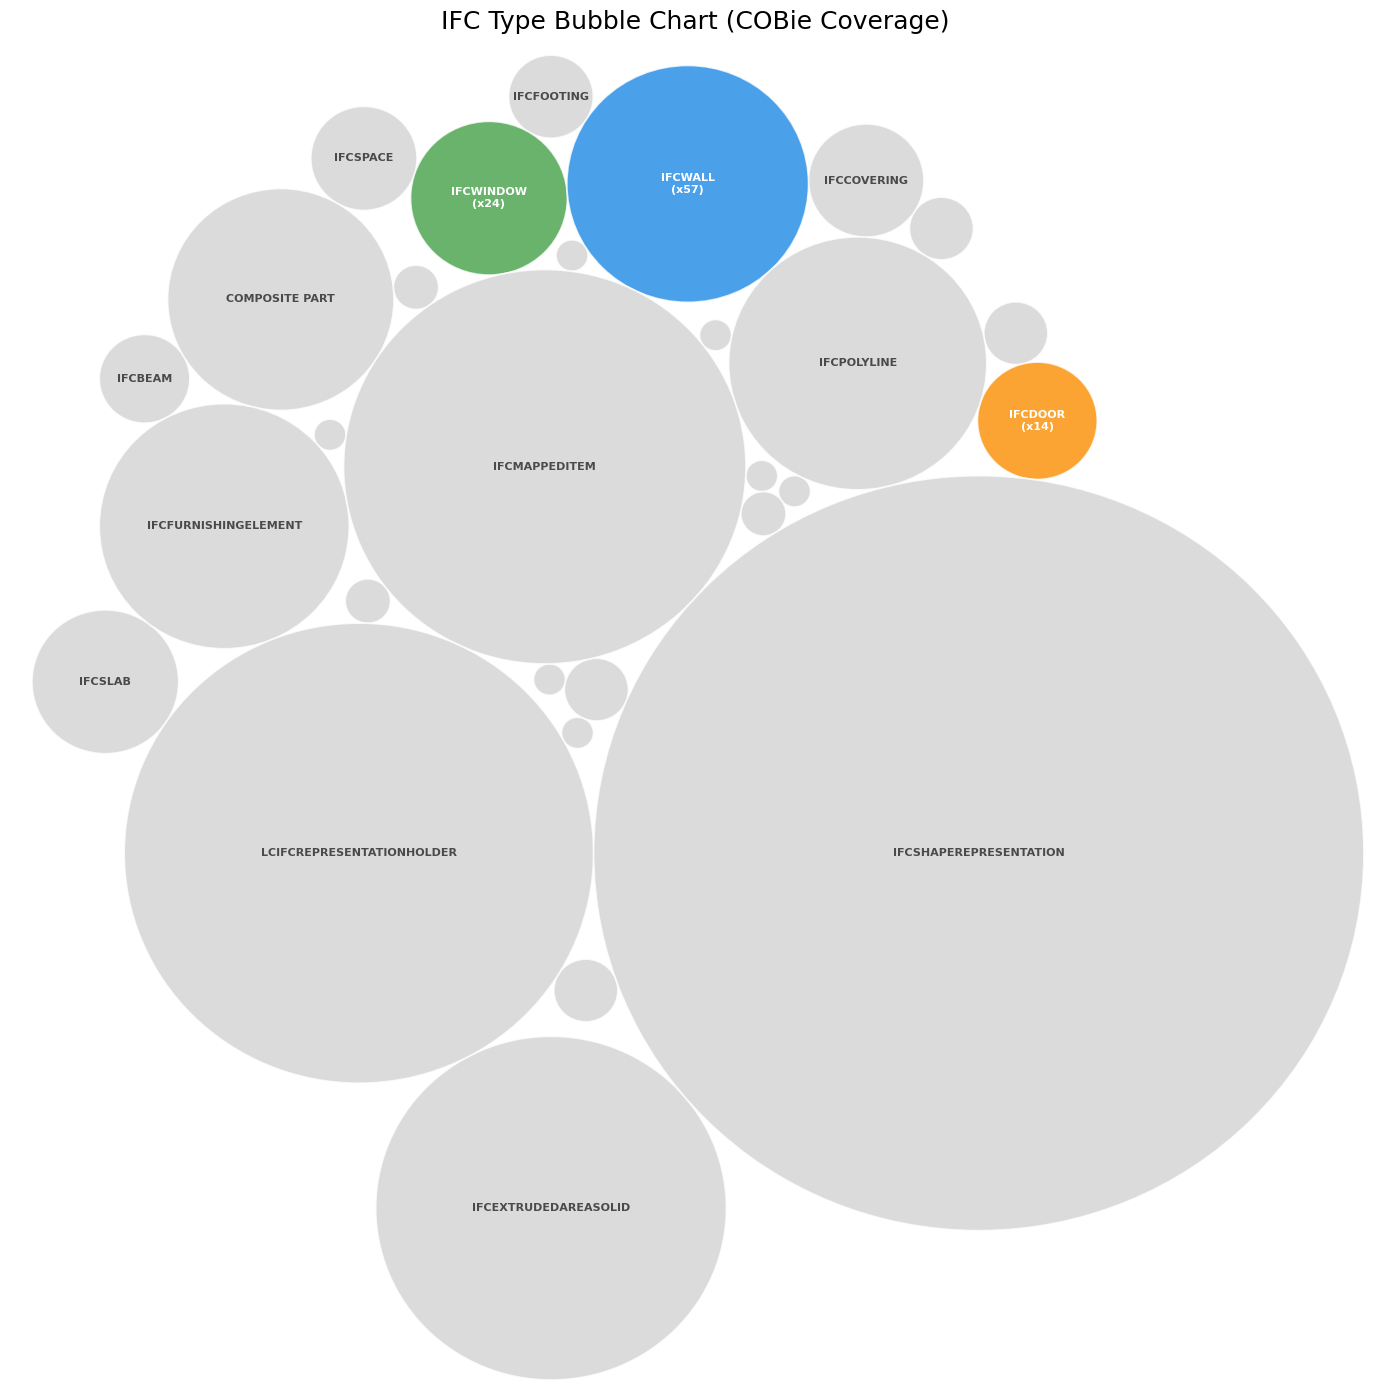

In [6]:
import matplotlib.pyplot as plt

try:
    import circlify
except ImportError:
    print("Package 'circlify' is not installed. Run: %pip install circlify")
else:
    if "after_df" not in globals() or after_df.empty:
        print("No data available. Run the previous cells first.")
    else:
        bubble_df = after_df.copy()
        bubble_df["IFC Type"] = bubble_df["IFC Type"].apply(normalize_ifc_type)

        # Treat null/empty COBie as unassigned.
        cobie_text = bubble_df["COBie Value"].fillna("").astype(str).str.strip()
        bubble_df["Has COBie"] = cobie_text.ne("")

        type_summary = (
            bubble_df.groupby("IFC Type", dropna=False)
            .agg(
                Total_Count=("IFC Type", "size"),
                COBie_Assigned_Count=("Has COBie", "sum"),
            )
            .reset_index()
        )
        type_summary["No_COBie_Count"] = type_summary["Total_Count"] - type_summary["COBie_Assigned_Count"]
        type_summary["Has_Any_COBie"] = type_summary["COBie_Assigned_Count"] > 0

        type_summary = type_summary.sort_values("Total_Count", ascending=False, kind="stable").reset_index(drop=True)

        if type_summary.empty:
            print("No IFC Type data to plot.")
        else:
            type_meta = {
                str(row["IFC Type"]): {
                    "has_cobie": bool(row["Has_Any_COBie"]),
                    "assigned": int(row["COBie_Assigned_Count"]),
                    "unassigned": int(row["No_COBie_Count"]),
                }
                for _, row in type_summary.iterrows()
            }

            circles_data = [
                {"id": str(row["IFC Type"]), "datum": int(row["Total_Count"])}
                for _, row in type_summary.iterrows()
                if int(row["Total_Count"]) > 0
            ]

            circles = circlify.circlify(
                circles_data,
                show_enclosure=False,
                target_enclosure=circlify.Circle(x=0, y=0, r=1),
            )

            fig, ax = plt.subplots(figsize=(14, 14))
            ax.set_title("IFC Type Bubble Chart (COBie Coverage)", fontsize=18)
            ax.axis("off")

            lim = max(
                max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
                for circle in circles
            )
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)

            assigned_types = type_summary[type_summary["Has_Any_COBie"]]["IFC Type"].tolist()
            assigned_palette = ["#1E88E5", "#43A047", "#FB8C00", "#8E24AA", "#00897B", "#D81B60", "#546E7A", "#FDD835"]
            assigned_color_map = {
                ifc_type: assigned_palette[i % len(assigned_palette)]
                for i, ifc_type in enumerate(assigned_types)
            }

            for circle in circles:
                if circle.level != 1:
                    continue

                x, y, r = circle
                ifc_type = str(circle.ex["id"])
                total_count = int(circle.ex.get("datum", 0))
                has_cobie = bool(type_meta.get(ifc_type, {}).get("has_cobie", False))

                facecolor = assigned_color_map.get(ifc_type, "#D3D3D3") if has_cobie else "#D3D3D3"

                ax.add_patch(
                    plt.Circle(  # type: ignore
                        (x, y),
                        r,
                        alpha=0.8,
                        linewidth=1.2,
                        edgecolor="white",
                        facecolor=facecolor,
                    )
                )

                if r > 0.06:
                    if has_cobie:
                        label = f"{ifc_type}\n(x{total_count})"
                        label_color = "white"
                    else:
                        label = ifc_type
                        label_color = "#4A4A4A"

                    ax.annotate(
                        label,
                        (x, y),
                        ha="center",
                        va="center",
                        fontsize=8,
                        color=label_color,
                        weight="bold",
                    )

            assigned_total = int(type_summary["COBie_Assigned_Count"].sum())
            unassigned_total = int(type_summary["No_COBie_Count"].sum())
            print(f"Total IFC Types plotted: {len(type_summary)}")
            print(f"Items with COBie assigned: {assigned_total}")
            print(f"Items without COBie assigned: {unassigned_total}")

            chart_base_name = BEFORE_PATH.stem
            chart_dir = ROOT / "GeneratedCharts"
            chart_dir.mkdir(parents=True, exist_ok=True)
            bubble_png_path = chart_dir / f"{chart_base_name}_ifc_type_cobie_bubble.png"
            fig.savefig(bubble_png_path, dpi=200, bbox_inches="tight")
            print(f"Saved bubble PNG: {bubble_png_path}")

            plt.tight_layout()
            plt.show()